In [1]:
import sys
from medvqa.scripts.training_scripts import train_phrase_grounding

PROJECT_ROOT: /home/pamessina/medvqa
DOTENV_PATH: /home/pamessina/medvqa/.env


2025-12-24 10:22:59.141927: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-24 10:23:01 | INFO     | root: Logging configured (Color: True).


In [2]:
# Simulate command-line arguments
sys.argv = [
    "notebook",  # argv[0] is the program name
    "--config_filepath", "/home/pamessina/medvqa/medvqa/configs/training/fgvlm_medsiglip_pg_chestimagenome_cnr.yaml",
    "--chest_imagenome_train_max_size", "2000",
    "--no_save",
]

# Call main
out = train_phrase_grounding.main(debug=True, no_resume=True)

2025-12-24 10:23:04 | INFO     | medvqa.utils.common: Total RAM: 503.57 GB
2025-12-24 10:23:04 | INFO     | medvqa.utils.common: Available RAM: 483.42 GB
2025-12-24 10:23:04 | INFO     | medvqa.utils.common: Used RAM: 12.29 GB (4.0%)
2025-12-24 10:23:04 | INFO     | medvqa.utils.common: 
script's arguments:
   config_filepath: None
   experiment_name: fgvlm_medsiglip_pg_chestimagenome_cnr
   epochs: 200
   batches_per_epoch: 400
   max_images_per_batch: 15
   max_phrases_per_batch: 1000
   max_phrases_per_image: 45
   val_batch_size_factor: 4
   checkpoint_folder_path: None
   pretrained_checkpoint_folder_path: None
   pretrained_checkpoint_folder_paths: None
   raw_image_encoding: medsiglip-448-huggingface
   huggingface_model_name: google/medsiglip-448
   num_regions: 1024
   image_local_feat_size: 1152
   image_encoder_pretrained_weights_path: None
   image_encoder_dropout_p: 0
   yolov8_model_name_or_path: None
   yolov8_model_alias: None
   phrase_embedding_size: 128
   regions_wi

In [3]:
out.keys()

dict_keys(['mimiccxr_trainer'])

In [4]:
from importlib import reload
import medvqa

In [ ]:
reload(medvqa.datasets.data_inspection_utils)

In [5]:
from medvqa.datasets.data_inspection_utils import (
    inspect_chest_imagenome_alg_item,
    inspect_chest_imagenome_pg_item,
)

In [ ]:
dataset = out['mimiccxr_trainer'].chest_imagenome_alg_train_dataset
inspect_chest_imagenome_alg_item(
    item=dataset[2],
    dataset=dataset,
    image_mean=[0.5, 0.5, 0.5],
    image_std=[0.5, 0.5, 0.5],
)

Visualizing Phrase Grounding Item
----------------------------------------
Index: 150
Image Path: /mnt/researchers/denis-parra/datasets/physionet.org/files/mimic-cxr-jpg/2.0.0/files/p13/p13983067/s56974052/e31a27bc-f0da0795-a58349cb-e6eb5572-ba9d3322.jpg
Phrase Text: Mild cardiomegaly
Num Original BBoxes: 1
Num Similar BBoxes: 5
Target Area Ratios: 0.5733720557932214
----------------------------------------


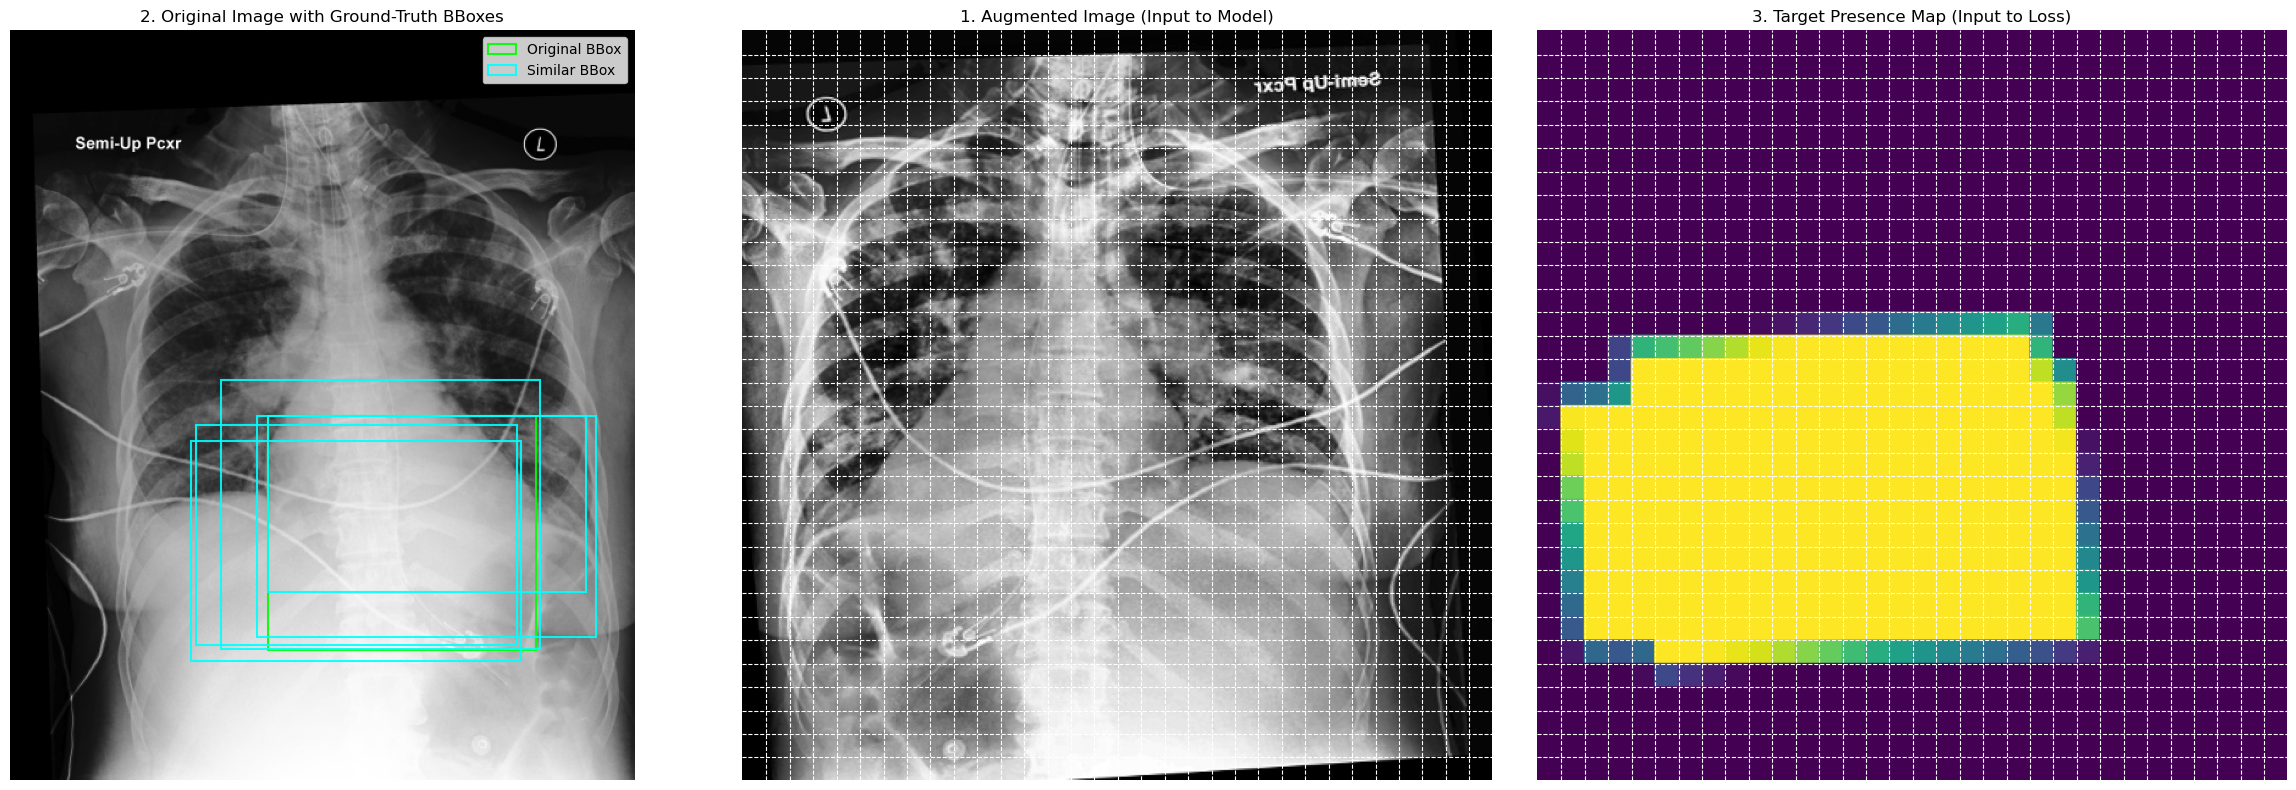

In [35]:
dataset = out['mimiccxr_trainer'].chest_imagenome_pg_train_dataset
inspect_chest_imagenome_pg_item(i=150, dataset=dataset,
                                image_mean=[0.5, 0.5, 0.5],
                                image_std=[0.5, 0.5, 0.5],
                                   )